In [ ]:
# import python library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Dataset
df_full = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/Titanic.csv')

In [ ]:
df_full

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df_full['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

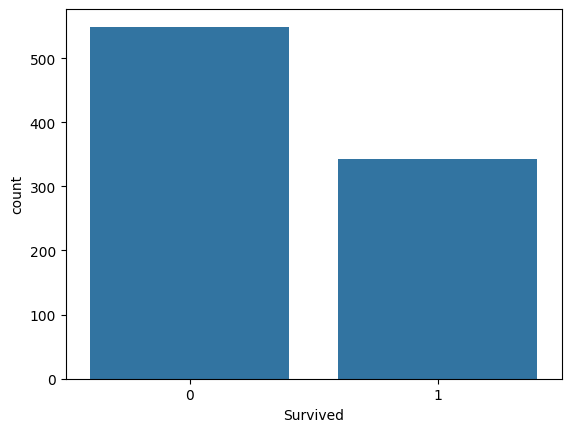

In [ ]:
# Plot Target Feature
sns.countplot(x='Survived', data=df_full)
plt.show()

In [ ]:
# Filled up missing value with the median
Age = df_full['Age'].fillna(value = df_full['Age'].median())

In [ ]:
# Drop unnecessary features
df_drop = df_full.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked', 'Age'], axis=1, inplace=True)

In [ ]:
df_full

,Survived,Pclass,Sex,Fare
0,0,3,male,7.2500
1,1,1,female,71.2833
2,1,3,female,7.9250
3,1,1,female,53.1000
4,0,3,male,8.0500
...,...,...,...,...
886,0,2,male,13.0000
887,1,1,female,30.0000
888,0,3,female,23.4500
889,1,1,male,30.0000


In [ ]:
# Concate Age with filled values
df = pd.concat([df_full, Age], axis=1)

In [ ]:
# Apply One Hot Encoder for Sex feature
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse=False, dtype=np.int32)

In [ ]:
df_ohe = ohe.fit_transform(df[['Sex']])

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
# Show all features value with Encoded value in an array
np.hstack((df[['Survived', 'Pclass', 'Age', 'Fare']].values, df_ohe))

array([[ 0.    ,  3.    , 22.    ,  7.25  ,  1.    ],
       [ 1.    ,  1.    , 38.    , 71.2833,  0.    ],
       [ 1.    ,  3.    , 26.    ,  7.925 ,  0.    ],
       ...,
       [ 0.    ,  3.    , 28.    , 23.45  ,  0.    ],
       [ 1.    ,  1.    , 26.    , 30.    ,  1.    ],
       [ 0.    ,  3.    , 32.    ,  7.75  ,  1.    ]])

In [ ]:
# Convert array to dataframe and rename Sex column to gender
Gender = pd.DataFrame(df_ohe, columns=['Gender'])
Gender.head(5)

,Gender
0,1
1,0
2,0
3,0
4,1


In [ ]:
# Concate gender column and drop sex column
dataset = pd.concat([df,Gender], axis=1).drop(columns=['Sex'])
dataset

,Survived,Pclass,Fare,Age,Gender
0,0,3,7.2500,22.0,1
1,1,1,71.2833,38.0,0
2,1,3,7.9250,26.0,0
3,1,1,53.1000,35.0,0
4,0,3,8.0500,35.0,1
...,...,...,...,...,...
886,0,2,13.0000,27.0,1
887,1,1,30.0000,19.0,0
888,0,3,23.4500,28.0,0
889,1,1,30.0000,26.0,1


In [ ]:
# Rename dataset to df
df = dataset
df

,Survived,Pclass,Fare,Age,Gender
0,0,3,7.2500,22.0,1
1,1,1,71.2833,38.0,0
2,1,3,7.9250,26.0,0
3,1,1,53.1000,35.0,0
4,0,3,8.0500,35.0,1
...,...,...,...,...,...
886,0,2,13.0000,27.0,1
887,1,1,30.0000,19.0,0
888,0,3,23.4500,28.0,0
889,1,1,30.0000,26.0,1


In [ ]:
# Define input and output/target features
X = df.drop(['Survived'], axis=1)
y = df['Survived']

In [ ]:
# Apply Scaler for input/independent features
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [ ]:
# Scale input/independent features
X_scale = scale.fit_transform(X)
X_scale

array([[ 0.82737724, -0.50244517, -0.56573646,  0.73769513],
       [-1.56610693,  0.78684529,  0.66386103, -1.35557354],
       [ 0.82737724, -0.48885426, -0.25833709, -1.35557354],
       ...,
       [ 0.82737724, -0.17626324, -0.1046374 , -1.35557354],
       [-1.56610693, -0.04438104, -0.25833709,  0.73769513],
       [ 0.82737724, -0.49237783,  0.20276197,  0.73769513]])

In [ ]:
# Apply SMOTE on X and y
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [ ]:
X_resampled, y_resampled = smote.fit_resample(X_scale, y)

In [ ]:
# Split train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [ ]:
# Apply KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# Observe KNN performance and pick the best performed K value
accuracy_train_list = []
accuracy_test_list  = []
f1_train_list       = []
f1_test_list        = []

for i in range(3, 13):
  print('k', i)

  KNN = KNeighborsClassifier(n_neighbors=i)
  KNN.fit(X_resampled, y_resampled)

  y_pred_train        = KNN.predict(X_train)

  accuracy_train      = accuracy_score(y_pred_train, y_train)
  accuracy_train_list.append(accuracy_train)

  f1_train = f1_score(y_pred_train, y_train)
  f1_train_list.append(f1_train)



  y_pred_test = KNN.predict(X_test)

  accuracy_test = accuracy_score(y_pred_test, y_test)
  accuracy_test_list.append(accuracy_test)

  f1_test = f1_score(y_pred_test, y_test)
  f1_test_list.append(f1_test)

  print(accuracy_train, accuracy_test)
  print(f1_train, f1_test, '\n')

k 3
0.9020501138952164 0.9181818181818182
0.9002320185614849 0.9237288135593219 

k 4
0.8644646924829157 0.9
0.852540272614622 0.9009009009009009 

k 5
0.8530751708428246 0.9090909090909091
0.8487690504103165 0.9145299145299145 

k 6
0.8530751708428246 0.8954545454545455
0.8424908424908425 0.8995633187772925 

k 7
0.8507972665148064 0.8772727272727273
0.8474970896391151 0.8841201716738197 

k 8
0.8439635535307517 0.8909090909090909
0.833939393939394 0.8938053097345133 

k 9
0.835990888382688 0.8772727272727273
0.8317757009345794 0.8860759493670887 

k 10
0.8325740318906606 0.8681818181818182
0.822249093107618 0.8755364806866952 

k 11
0.8291571753986332 0.8545454545454545
0.8255813953488371 0.865546218487395 

k 12
0.8280182232346242 0.8636363636363636
0.8182912154031289 0.8706896551724138 



In [ ]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [ ]:
# Apply GridSearchCV
parameters = {'n_neighbors':list(range(3,13))}
KNN = KNeighborsClassifier()
clf = GridSearchCV(KNN, parameters)
clf.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]})

In [ ]:
# Which iteration of K's accuracy is best
clf.best_params_

{'n_neighbors': 4}

#**K Nearest Neighbors**

In [ ]:
# Apply KNN on best performed K value
KNN = KNeighborsClassifier(n_neighbors=4)
KNN.fit(X_train, y_train)

y_pred_train = KNN.predict(X_train)
accuracy_train = accuracy_score(y_pred_train, y_train)
f1_train = f1_score(y_pred_train, y_train)

y_pred_test = KNN.predict(X_test)
accuracy_test = accuracy_score(y_pred_test, y_test)
f1_test = f1_score(y_pred_test, y_test)

In [ ]:
# Apply Classification Report
from sklearn.metrics import classification_report
target_names = ['Survived', 'Not Survived']

In [ ]:
# Show the over all performance on train data
print('Train Data of KNN: ','\n')
print('Accuracy on Train Data: ', accuracy_train, '\n')
print('F1_Score on Train Data: ', f1_train, '\n')
print('Classification Report on Train Data: ', '\n', '\n', classification_report(y_train, y_pred_train, target_names=target_names))

Train Data of KNN:  

Accuracy on Train Data:  0.857630979498861 

F1_Score on Train Data:  0.8435544430538172 

Classification Report on Train Data:  
 
               precision    recall  f1-score   support

    Survived       0.81      0.93      0.87       446
Not Survived       0.92      0.78      0.84       432

    accuracy                           0.86       878
   macro avg       0.87      0.86      0.86       878
weighted avg       0.87      0.86      0.86       878



In [ ]:
# Show the over all performance on test data
print('Test Data of KNN: ','\n')
print('Accuracy on Test Data: ', accuracy_test, '\n' )
print('F1 Score on Test Data: ', f1_test, '\n')
print('Classification Report on Test Data: ', '\n','\n', classification_report(y_test, y_pred_test, target_names=target_names))

Test Data of KNN:  

Accuracy on Test Data:  0.8318181818181818 

F1 Score on Test Data:  0.8340807174887892 

Classification Report on Test Data:  
 
               precision    recall  f1-score   support

    Survived       0.79      0.87      0.83       103
Not Survived       0.88      0.79      0.83       117

    accuracy                           0.83       220
   macro avg       0.83      0.83      0.83       220
weighted avg       0.84      0.83      0.83       220



In [ ]:
# Apply Confusion Matrix
from sklearn.metrics import confusion_matrix
c_train = confusion_matrix(y_pred_train, y_train)
c_test  = confusion_matrix(y_pred_test, y_test)

In [ ]:
# Results of Confusion Matrix on train and test data
print('Confusion Matrix on Train Data: ','\n', c_train, '\n')
print('Confusion Matrix on Test  Data: ', '\n', c_test)

Confusion Matrix on Train Data:  
 [[416  95]
 [ 30 337]] 

Confusion Matrix on Test  Data:  
 [[90 24]
 [13 93]]


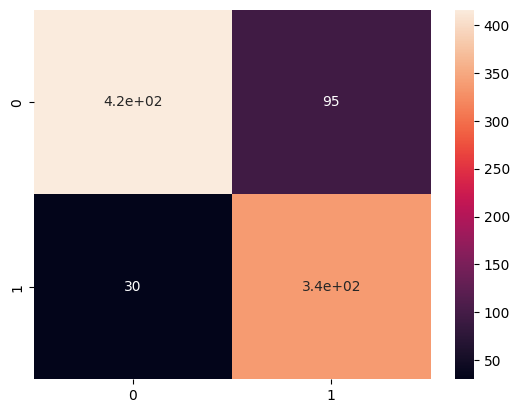

In [ ]:
# Apply heatmap on train Data
sns.heatmap(c_train, annot=True)
plt.show()

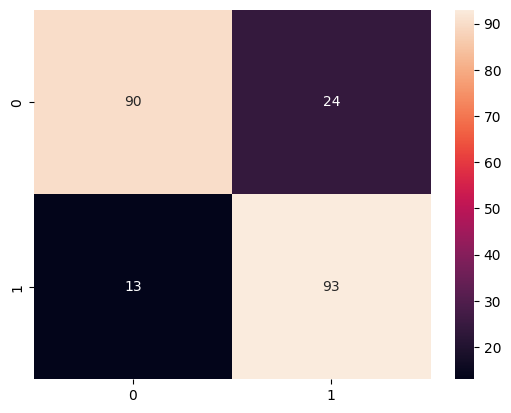

In [ ]:
# Apply heatmap on test Data
sns.heatmap(c_test, annot=True)
plt.show()